# 重現性設定

In [1]:
import os
import numpy as np
import random
import tensorflow as tf

# 設定環境變數
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

# 設定執行緒
try:
    tf.config.threading.set_inter_op_parallelism_threads(1)
    tf.config.threading.set_intra_op_parallelism_threads(1)
except RuntimeError as e:
    print(f"警告：設定失敗，原因可能是環境已初始化。{e}")

# 設定所有隨機種子
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("環境配置完成！")

環境配置完成！


# 載入資料集與預處理

In [2]:
from tensorflow.keras.datasets import cifar10
import tensorflow as tf
import numpy as np

# 載入資料集
(X_train_image, y_train_label), (X_test_image, y_test_label) = cifar10.load_data()

# reshape 轉成1維
y_train_label = y_train_label.reshape(-1)
y_test_label = y_test_label.reshape(-1)

# 進行標準化
X_train_normalize = X_train_image.astype('float32') / 255.0
X_test_normalize = X_test_image.astype('float32') / 255.0

# One-hot Encoding處理
from tensorflow.keras import utils

y_train_onehot = utils.to_categorical(y_train_label)
y_test_onehot = utils.to_categorical(y_test_label)

print('Train Data images:',X_train_normalize.shape)
print('Train Data labels:',y_train_onehot.shape)
print('Test Data images:',X_test_normalize.shape)
print('Test Data labels:',y_test_onehot.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Train Data images: (50000, 32, 32, 3)
Train Data labels: (50000, 10)
Test Data images: (10000, 32, 32, 3)
Test Data labels: (10000, 10)


# 函數建立模型

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization

def build_model(model, p_bname, p_conv, p_filters, p_drop_rate, p_is_bn): # model, block名稱, 卷積層數量, 卷積層參數數量, 卷積層參數大小, 丟棄層, BatchNormalization
    # 1. 卷積層循環 (名稱隨 i 變動)
    for i in range(p_conv):
        model.add(Conv2D(
            filters=p_filters,
            kernel_size=(3, 3),
            activation='relu',
            padding='same',
            name=f"{p_bname}_conv{i+1}"
        ))
        if p_is_bn:
            model.add(BatchNormalization(name=f"{p_bname}_bn{i+1}"))

    # 2. Block 結尾層 (名稱僅包含 block 名稱，不再重疊)
    model.add(MaxPooling2D(pool_size=(2, 2), name=f"{p_bname}_pool"))

    if p_is_bn:
        model.add(BatchNormalization(name=f"{p_bname}_pool_bn_end"))

    if p_drop_rate > 0:
        model.add(Dropout(p_drop_rate, name=f"{p_bname}_dropout"))

In [10]:
drop_rate = 0 # Batch Normalization 與 Dropout合併使用，會產生方差偏移的問題
model = Sequential()
model.add(Input(shape=(32, 32, 3)))
build_model(model, p_bname='block1', p_conv=6, p_filters=32, p_drop_rate=drop_rate, p_is_bn=True)
build_model(model, p_bname='block2', p_conv=6, p_filters=64, p_drop_rate=drop_rate, p_is_bn=True)
build_model(model, p_bname='block3', p_conv=6, p_filters=128, p_drop_rate=drop_rate, p_is_bn=True)

model.add(Flatten())
model.add(BatchNormalization())
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(10, activation='softmax'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn1 (BatchNormalization) │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn2 (BatchNormalization) │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv3 (Conv2D)           │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn3 (BatchNormalization) │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv4 (Conv2D)           │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn4 (BatchNormalization) │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv5 (Conv2D)           │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn5 (BatchNormalization) │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv6 (Conv2D)           │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn6 (BatchNormalization) │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool_bn_end              │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn1 (BatchNormalization) │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn2 (BatchNormalization) │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv3 (Conv2D)           │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn3 (BatchNormalization) │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv4 (Conv2D)           │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn4 (BatchNormalization) │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv5 (Conv2D)           │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn5 (BatchNormalization) │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,340,586 (5.11 MB)

 Trainable params: 1,333,098 (5.09 MB)

 Non-trainable params: 7,488 (29.25 KB)

# EarlyStopping與ModelCheckpoint

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    mode='min',)

In [12]:
!mkdir Model

In [13]:
filepath = 'Model/cifar10_model.h5'
checkpoint = ModelCheckpoint(
    filepath=filepath,
    monitor='val_acc',
    save_best_only=True,
    mode='max')

In [14]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['acc'])

train_history = model.fit(
    x=X_train_normalize,
    y=y_train_onehot,
    validation_split=0.2,
    epochs=200,
    batch_size=100,
    verbose=2,
    callbacks=[early_stopping,checkpoint])

Epoch 1/200


400/400 - 50s - 124ms/step - acc: 0.4449 - loss: 1.9571 - val_acc: 0.2755 - val_loss: 2.6897
Epoch 2/200


400/400 - 31s - 79ms/step - acc: 0.5932 - loss: 1.3199 - val_acc: 0.5708 - val_loss: 1.4097
Epoch 3/200


400/400 - 32s - 80ms/step - acc: 0.6775 - loss: 1.0124 - val_acc: 0.6192 - val_loss: 1.2376
Epoch 4/200


400/400 - 32s - 81ms/step - acc: 0.7342 - loss: 0.8465 - val_acc: 0.6472 - val_loss: 1.1254
Epoch 5/200


...

400/400 - 33s - 82ms/step - acc: 0.9913 - loss: 0.0610 - val_acc: 0.8201 - val_loss: 0.8415
Epoch 53/200
400/400 - 33s - 82ms/step - acc: 0.9905 - loss: 0.0633 - val_acc: 0.7945 - val_loss: 1.0219
Epoch 54/200
400/400 - 33s - 81ms/step - acc: 0.9876 - loss: 0.0735 - val_acc: 0.8165 - val_loss: 0.9394
Epoch 55/200
400/400 - 41s - 102ms/step - acc: 0.9922 - loss: 0.0577 - val_acc: 0.8127 - val_loss: 0.9365
Epoch 56/200
400/400 - 33s - 81ms/step - acc: 0.9928 - loss: 0.0530 - val_acc: 0.8180 - val_loss: 0.9540
Epoch 57/200
400/400 - 33s - 82ms/step - acc: 0.9875 - loss: 0.0728 - val_acc: 0.8038 - val_loss: 0.9768
Epoch 58/200
400/400 - 33s - 82ms/step - acc: 0.9890 - loss: 0.0669 - val_acc: 0.8197 - val_loss: 0.8402
Epoch 59/200
400/400 - 34s - 85ms/step - acc: 0.9930 - loss: 0.0500 - val_acc: 0.8167 - val_loss: 0.8895
Epoch 60/200


400/400 - 33s - 82ms/step - acc: 0.9926 - loss: 0.0528 - val_acc: 0.8246 - val_loss: 0.8854
Epoch 61/200
400/400 - 33s - 82ms/step - acc: 0.9924 - loss: 0.0533 - val_acc: 0.8107 - val_loss: 0.9569
Epoch 62/200
400/400 - 33s - 82ms/step - acc: 0.9913 - loss: 0.0582 - val_acc: 0.8164 - val_loss: 0.9301
Epoch 63/200
400/400 - 33s - 81ms/step - acc: 0.9941 - loss: 0.0477 - val_acc: 0.8240 - val_loss: 0.8752
Epoch 64/200


400/400 - 33s - 82ms/step - acc: 0.9944 - loss: 0.0437 - val_acc: 0.8281 - val_loss: 0.8589
Epoch 65/200
400/400 - 33s - 82ms/step - acc: 0.9901 - loss: 0.0583 - val_acc: 0.8187 - val_loss: 0.9165
Epoch 66/200
400/400 - 33s - 81ms/step - acc: 0.9911 - loss: 0.0559 - val_acc: 0.8240 - val_loss: 0.8908
Epoch 67/200


400/400 - 33s - 82ms/step - acc: 0.9951 - loss: 0.0399 - val_acc: 0.8290 - val_loss: 0.8285
Epoch 68/200
400/400 - 33s - 82ms/step - acc: 0.9942 - loss: 0.0416 - val_acc: 0.8145 - val_loss: 0.9650
Epoch 69/200
400/400 - 33s - 81ms/step - acc: 0.9916 - loss: 0.0539 - val_acc: 0.8239 - val_loss: 0.8855
Epoch 70/200
400/400 - 33s - 82ms/step - acc: 0.9952 - loss: 0.0403 - val_acc: 0.8215 - val_loss: 0.8821
Epoch 71/200
400/400 - 33s - 82ms/step - acc: 0.9910 - loss: 0.0542 - val_acc: 0.8239 - val_loss: 0.8977
Epoch 72/200
400/400 - 33s - 82ms/step - acc: 0.9928 - loss: 0.0474 - val_acc: 0.8268 - val_loss: 0.8831
Epoch 73/200
400/400 - 33s - 82ms/step - acc: 0.9945 - loss: 0.0407 - val_acc: 0.8098 - val_loss: 0.9983
Epoch 74/200
400/400 - 33s - 82ms/step - acc: 0.9951 - loss: 0.0408 - val_acc: 0.8199 - val_loss: 0.9392
Epoch 75/200
400/400 - 33s - 82ms/step - acc: 0.9938 - loss: 0.0426 - val_acc: 0.8276 - val_loss: 0.8717
Epoch 76/200
400/400 - 33s - 82ms/step - acc: 0.9941 - loss: 0.0414 

400/400 - 33s - 83ms/step - acc: 0.9976 - loss: 0.0265 - val_acc: 0.8357 - val_loss: 0.8308


# 圖形顯示過程

In [15]:
import matplotlib.pyplot as plt

def show_train_history(train_history, train_key, validation_key):
    plt.plot(train_history.history[train_key], '--')
    plt.plot(train_history.history[validation_key])
    plt.title('Train History')
    plt.ylabel(train_key)
    plt.xlabel('Epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

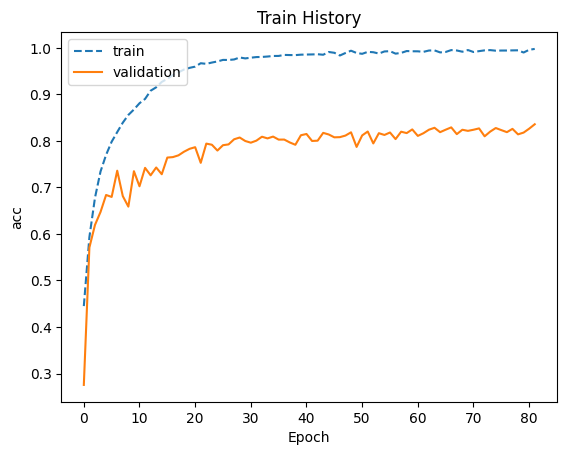

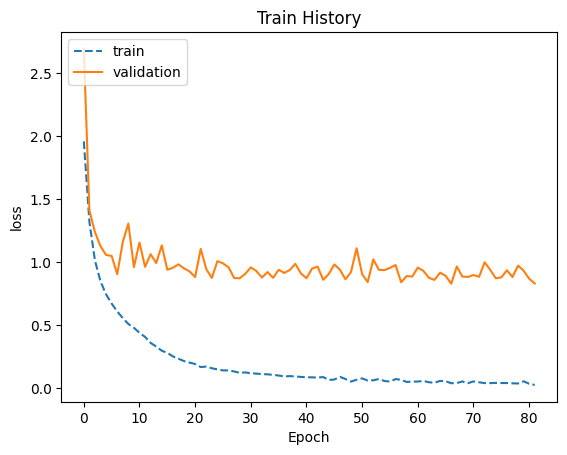

In [16]:
show_train_history(train_history, 'acc', 'val_acc')
show_train_history(train_history, 'loss', 'val_loss')

# 測試模型

In [17]:
scores = model.evaluate(X_test_normalize, y_test_onehot, verbose=2)
print('Test Accuracy:', scores[1])
print('Test Loss:', scores[0])

313/313 - 4s - 12ms/step - acc: 0.8278 - loss: 0.8574
Test Accuracy: 0.8277999758720398
Test Loss: 0.8574162125587463
